[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/AnirbanKopty/GWFC_DAT/blob/main/Session1/Tutorial/01_Generate_Gaussian_Noise.ipynb)

# Tutorial 1: Generate Gaussian Noise
In this notebook, we will generate both white and colored Gaussian noise using PyCBC.

> ⚠️ **Warning**: 
> Uncomment and run the following cell to install necessary packages, if running in Google Collab.  
> Restart the runtime after running the cell below. To do so, go to "Runtime" and select "Restart session".

In [ ]:
# !pip install pycbc

In [ ]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import matplotlib.pyplot as plt

import pycbc.noise
import pycbc.psd


In [2]:
flow = 20.0
sample_rate = 4096
duration = 128
samples = int(sample_rate * duration)

delta_f = 1.0 / duration
flen = int(sample_rate / (2 * delta_f)) + 1


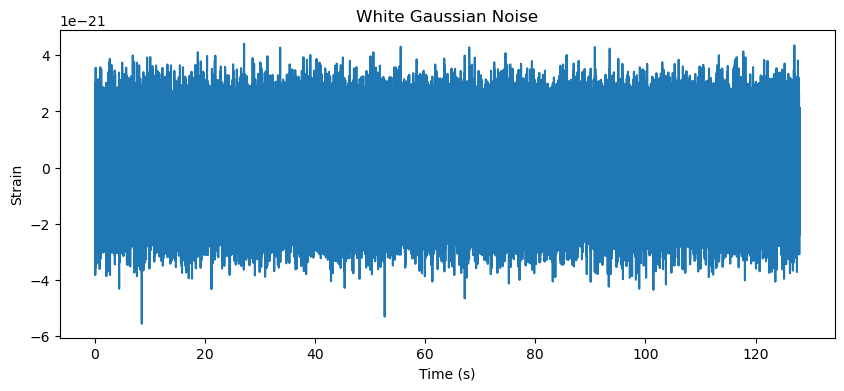

In [ ]:
# Generate White Noise
white_noise = np.random.normal(0, 1, size=samples) * 1e-21
times = np.arange(samples) / sample_rate

plt.figure(figsize=(10, 4))
plt.plot(times, white_noise)
plt.title('White Gaussian Noise')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.show()

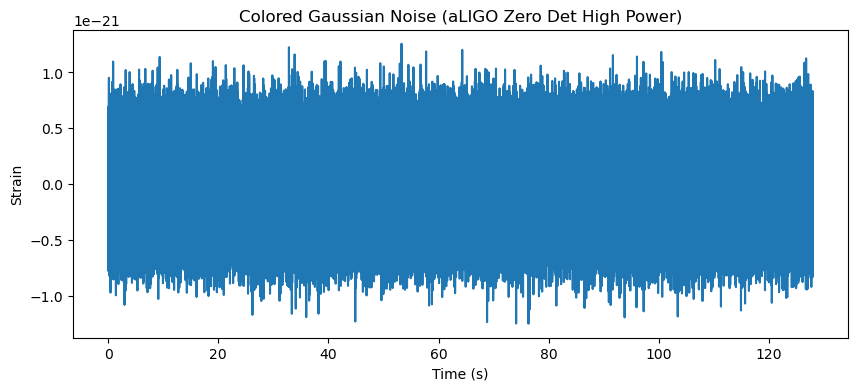

In [ ]:
# Generate Colored Noise from aLIGO PSD
delta_t = 1.0 / sample_rate
delta_f = 1.0 / duration
flen = int(sample_rate / (2 * delta_f)) + 1

psd = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, flow)

colored_noise = pycbc.noise.gaussian.noise_from_psd(duration * sample_rate, delta_t, psd, seed=127)

plt.figure(figsize=(10, 4))
plt.plot(colored_noise.sample_times, colored_noise)
plt.title('Colored Gaussian Noise (aLIGO Zero Det High Power)')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.show()


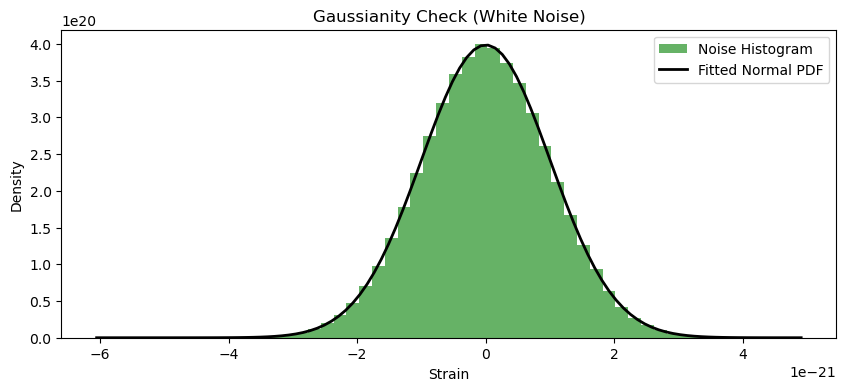

In [ ]:
# Verifying Gaussianity

from scipy.stats import norm

plt.figure(figsize=(10, 4))
data = white_noise

# Fit a normal distribution to our data
mu, std = norm.fit(data)

# Plot the histogram
plt.hist(data, bins=50, density=True, alpha=0.6, color='g', label='Noise Histogram')

# Plot the theoretical PDF
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label='Fitted Normal PDF')

plt.title('Gaussianity Check (White Noise)')
plt.xlabel('Strain')
plt.ylabel('Density')
plt.legend()
plt.show()


In [ ]:
# Checking White vs Colored Noise
# Note: In Tutorial 2 we will explore PSD estimation more deeply.

from scipy.signal import welch

segment_duration = 4.0  # seconds
seg_len = int(segment_duration * sample_rate)
seg_stride = int(seg_len / 2)
freqs, white_psd_est = welch(white_noise, fs=sample_rate,
                      nperseg=seg_len, noverlap=seg_len - seg_stride)
colored_psd_est = colored_noise.psd(segment_duration)


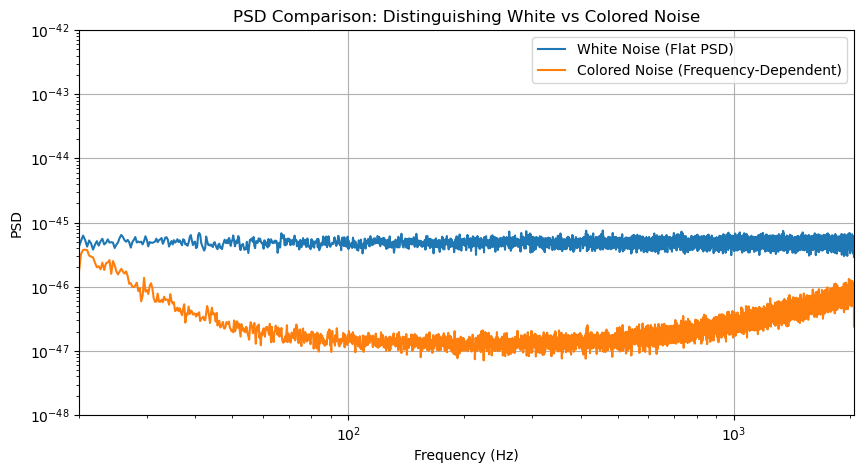

In [7]:
plt.figure(figsize=(10, 5))
plt.loglog(freqs, white_psd_est,
           label='White Noise (Flat PSD)')
plt.loglog(colored_psd_est.sample_frequencies, colored_psd_est,
           label='Colored Noise (Frequency-Dependent)')
plt.xlim(20, 2048)
plt.ylim(1e-48, 1e-42)
plt.title('PSD Comparison: Distinguishing White vs Colored Noise')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.legend()
plt.grid(True)
plt.show()